# Decoerência de Qubits sob a Equação de Lindblad: Simulação Numérica e Roteiro Didático com QuTiP

**Autores:** Allan Miqueias de C. Santos · Wedryson Lucas X. O. Souza  
**Instituição:** UFERSA - Programa de Pós-Graduação em Engenharia Elétrica  

---

## Estrutura do notebook

| Seção | Corresponde a |
|---|---|
| 1. Instalação e Importações | --- |
| 2. Modelo e Funções Base | Seções II e III do artigo |
| 3. Varredura Paramétrica 4×4 | Seção III.A |
| 4. Análise e Consolidação | Seção III.B–C |
| 5. Resultados — Curvas Temporais | Seção IV.A |
| 6. Resultados — Vetor de Bloch | Seção IV.B |
| 7. Resultados — Convergência Temporal | Seção IV.C |
| 8. Resultados — Invariância ao Estado Inicial | Seção IV.D |
| 9. Resultados — Mapas Paramétricos | Seção IV.E |
| 10. Resultados — Validação Numérica vs. Teórica | Seção IV.F |
| 11. Relatório Final |


## 1. Instalação e Importações

In [1]:
!pip install qutip --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 43.1 MB/s eta 0:00:00


In [3]:
import os, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import qutip as qt
from qutip import basis, sigmax, sigmay, sigmaz, sigmam, mesolve, ket2dm

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 130,
})
sns.set_palette('husl')

RESULTS_DIR = 'results'
FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
TABLES_DIR  = os.path.join(RESULTS_DIR, 'tables')
for d in [RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'QuTiP {qt.__version__} | NumPy {np.__version__}')
print('✓ Importações concluídas')


QuTiP 5.2.3 | NumPy 2.0.2
✓ Importações concluídas


## 2. Modelo e Funções Base

Implementa o Hamiltoniano (Eq. 2), os operadores de Lindblad (Eq. 3),
as relações teóricas T₁/T₂ (Eq. 4), o Tfinal adaptativo (Eq. 6)
e o ajuste exponencial robusto sobre |ρ₀₁(t)| com ±1σ e R² (Seção III.C).


In [4]:
# ================================================================
# CÉLULA 2 — Parâmetros globais e funções base
# ================================================================

omega0 = 2 * np.pi * 1.0
H      = 0.5 * omega0 * sigmaz()

# Grade de parâmetros
gamma1_list = [0.0, 0.05, 0.2, 1.0]
gphi_list   = [0.0, 0.1,  0.5, 2.0]

# Estado inicial padrão do artigo
psi_plus = (basis(2, 0) + basis(2, 1)).unit()

# -----------------------------------------------
# Fórmulas teóricas (Eq. 4 do artigo)
# -----------------------------------------------
def T2_teor(gamma1, gphi):
    """1/T2 = gamma1/2 + gphi"""
    taxa = 0.5 * gamma1 + gphi
    return np.inf if taxa == 0 else 1.0 / taxa

def T1_teor(gamma1):
    return np.inf if gamma1 == 0 else 1.0 / gamma1

def tfinal_adaptativo(gamma1, gphi, fator=8.0, tf_min=25.0, tf_max=200.0):
    """
    Tfinal = 8 × min(T₁, T₂), limitado entre tf_min=25 e tf_max=200 u.a.
    Reproduz exatamente os valores da Tabela II do artigo.
    """
    tempos = [T1_teor(gamma1), T2_teor(gamma1, gphi)]
    finitos = [t for t in tempos if np.isfinite(t)]
    if not finitos:
        return tf_min
    tau_ref = min(finitos)
    return float(np.clip(fator * tau_ref, tf_min, tf_max))

# -----------------------------------------------
# Ajuste exponencial com R² e ±1σ
# -----------------------------------------------
def ajusta_exp(t, y):
    """
    y(t) = A*exp(-t/tau) + C sobre a série completa.
    Retorna: tau, err_tau (1σ), R², curva ajustada.
    """
    def modelo(t, A, tau, C):
        return A * np.exp(-t / tau) + C

    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]

    if len(t) < 10:
        return dict(tau=np.nan, err=np.nan, R2=np.nan, curva=np.full_like(t, np.nan))

    if np.allclose(y, y[0], rtol=1e-4, atol=1e-8):
        return dict(tau=np.inf, err=np.nan, R2=1.0, curva=y.copy())

    A0  = max(float(y[0] - y[-1]), 1e-9)
    C0  = float(y[-1])
    alvo = A0 / np.e + C0
    idx  = np.searchsorted(-y, -alvo)
    tau0 = float(t[min(idx, len(t)-1)]) if idx < len(t) else t[-1]/3
    tau0 = max(tau0, 1e-6)

    try:
        popt, pcov = curve_fit(modelo, t, y,
                               p0=[A0, tau0, C0],
                               bounds=([0, 1e-9, -1], [2.0, t[-1]*20, 1.0]),
                               maxfev=20000)
        A, tau, C = popt
        err = float(np.sqrt(np.diag(pcov))[1])
        residuos = y - modelo(t, *popt)
        ss_tot   = np.sum((y - y.mean())**2)
        R2 = float(1 - np.sum(residuos**2) / ss_tot) if ss_tot > 0 else np.nan
        return dict(tau=float(tau), err=err, R2=R2, curva=modelo(t, *popt))
    except Exception:
        return dict(tau=np.nan, err=np.nan, R2=np.nan, curva=np.full_like(t, np.nan))

def simular(gamma1, gphi, tlist, psi0=None):
    """Roda mesolve e devolve estados."""
    if psi0 is None:
        psi0 = psi_plus
    c_ops = []
    if gamma1 > 0:
        c_ops.append(np.sqrt(gamma1) * sigmam())
    if gphi > 0:
        c_ops.append(np.sqrt(gphi / 2.0) * sigmaz())
    res = mesolve(H, psi0, tlist, c_ops, [],
                  options={'store_states': True, 'nsteps': 10000})
    return res.states

def extrair_obs(states):
    """
    Extrai |ρ₀₁|, Pₑ e ⟨σx⟩ de uma lista de estados.
    Converte kets para matriz densidade.
    Isso é necessário porque sem c_ops o QuTiP retorna kets (shape 2×1)
    em vez de matrizes densidade (shape 2×2).
    """
    def to_dm(r):
        """Converte ket para dm se necessário."""
        if r.isket:
            return r.proj()   # |ψ⟩⟨ψ|
        return r

    rhos  = [to_dm(r) for r in states]
    rho01 = np.array([abs(r.full()[0,1]) for r in rhos])
    Pe    = np.array([float(np.real(r.full()[1,1])) for r in rhos])
    sx    = np.array([float(np.real((r * sigmax()).tr())) for r in rhos])
    return rho01, Pe, sx

print('Funções base definidas.')

Funções base definidas.


## 3. Varredura Paramétrica 4×4

Simula todos os 16 pares `(γ₁, γ_φ)` da grade do artigo.  
Salva `results/summary.csv`, `results/all_results.pkl` e um CSV por caso.


In [5]:
# ============================================================
# 3. Varredura paramétrica 4×4
# Usa |ρ₀₁(t)| para estimar T₂
# Tfinal adaptativo = 8×(T₁​,T₂) com limites [25, 200] u.a.
# Reporta T₂ ± 1σ e R² para cada caso
# ============================================================

import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qutip import basis, sigmax, sigmay, sigmaz, sigmam, mesolve

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

summary_rows = []
all_results  = {}

print(f'Iniciando varredura 4×4 ({len(gamma1_list)*len(gphi_list)} casos)\n')

for gamma1 in gamma1_list:
    for gphi in gphi_list:
        tag = f'g1_{gamma1}_gphi_{gphi}'

        # ── Tfinal adaptativo (Eq. 6 do artigo) ──────────────────────────
        Tf   = tfinal_adaptativo(gamma1, gphi)
        tlist = np.linspace(0, Tf, 800)

        # ── Simulação ─────────────────────────────────────────────────────
        states = simular(gamma1, gphi, tlist)

        # ── Observáveis ───────────────────────────────────────────────────
        def to_dm(r):
            return r.proj() if r.isket else r

        rhos = [to_dm(r) for r in states]

        # |ρ₀₁(t)| — grandeza usada para estimar T₂ (Seção III.C)
        rho01 = np.array([abs(r.full()[0, 1]) for r in rhos])

        # Fidelidade em relação à evolução ideal
        psi_id_t = [((-1j * H * t).expm() * psi_plus) for t in tlist]
        fidelity = []
        for k, rho in enumerate(rhos):
            raw = psi_id_t[k].dag() * rho * psi_id_t[k]
            fidelity.append(float(np.real(raw.tr() if hasattr(raw, 'tr') else raw)))

        purity = np.array([float(np.real((r * r).tr())) for r in rhos])
        sx_arr = np.array([float(np.real((r * sigmax()).tr())) for r in rhos])
        sy_arr = np.array([float(np.real((r * sigmay()).tr())) for r in rhos])
        sz_arr = np.array([float(np.real((r * sigmaz()).tr())) for r in rhos])
        fidelity = np.array(fidelity)

        # ── Ajuste exponencial sobre |ρ₀₁(t)| ────────────────────────────
        fit = ajusta_exp(tlist, rho01)   # função da Seção 2
        T2_num = fit['tau']
        T2_err = fit['err']
        R2     = fit['R2']

        # ── Salvar CSV do caso ────────────────────────────────────────────
        df = pd.DataFrame({
            't': tlist, 'rho01': rho01,
            'fidelity': fidelity, 'purity': purity,
            'sx': sx_arr, 'sy': sy_arr, 'sz': sz_arr,
            'gamma1': gamma1, 'gphi': gphi, 'tag': tag,
        })
        df.to_csv(os.path.join(RESULTS_DIR, f'{tag}.csv'), index=False)

        # ── Acumular resultados ───────────────────────────────────────────
        all_results[tag] = {
            'params': (gamma1, gphi), 'tlist': tlist,
            'rho01': rho01, 'fidelity': fidelity, 'purity': purity,
            'sx': sx_arr, 'sy': sy_arr, 'sz': sz_arr,
            'T2_num': T2_num, 'T2_err': T2_err, 'R2': R2,
            'Tfinal': Tf,
        }
        summary_rows.append({
            'tag': tag, 'gamma1': gamma1, 'gphi': gphi,
            'T2_num': T2_num, 'T2_err': T2_err, 'R2': R2,
            'Tfinal': Tf,
            'fidelity_final': float(fidelity[-1]),
            'purity_final':   float(purity[-1]),
        })

        # Log
        T2_str = f'{T2_num:.4f} ± {T2_err:.2e}' if np.isfinite(T2_num) else '∞'
        print(f'  {tag:<28s}  Tf={Tf:6.1f}  T₂={T2_str}  R²={R2:.5f}')

# ── Salvar summary.csv e all_results.pkl ─────────────────────────────────────
summary = pd.DataFrame(summary_rows)
summary.to_csv(os.path.join(RESULTS_DIR, 'summary.csv'), index=False)
with open(os.path.join(RESULTS_DIR, 'all_results.pkl'), 'wb') as fh:
    pickle.dump(all_results, fh)

print(f'\n✓ {len(summary_rows)} casos concluídos')
print(f'  summary.csv e all_results.pkl salvos em: {os.path.abspath(RESULTS_DIR)}')


Iniciando varredura 4×4 (16 casos)

  g1_0.0_gphi_0.0               Tf=  25.0  T₂=∞  R²=1.00000
  g1_0.0_gphi_0.1               Tf=  80.0  T₂=9.9961 ± 2.70e-05  R²=1.00000


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


  g1_0.0_gphi_0.5               Tf=  25.0  T₂=1.9999 ± 1.79e-06  R²=1.00000
  g1_0.0_gphi_2.0               Tf=  25.0  T₂=0.5000 ± 2.58e-08  R²=1.00000
  g1_0.05_gphi_0.0              Tf= 160.0  T₂=39.9381 ± 4.72e-05  R²=1.00000
  g1_0.05_gphi_0.1              Tf=  64.0  T₂=7.9982 ± 2.46e-05  R²=1.00000
  g1_0.05_gphi_0.5              Tf=  25.0  T₂=1.9046 ± 9.43e-07  R²=1.00000
  g1_0.05_gphi_2.0              Tf=  25.0  T₂=0.4938 ± 2.43e-08  R²=1.00000
  g1_0.2_gphi_0.0               Tf=  40.0  T₂=9.9964 ± 3.72e-05  R²=1.00000
  g1_0.2_gphi_0.1               Tf=  40.0  T₂=4.9992 ± 7.94e-06  R²=1.00000
  g1_0.2_gphi_0.5               Tf=  25.0  T₂=1.6666 ± 1.53e-07  R²=1.00000
  g1_0.2_gphi_2.0               Tf=  25.0  T₂=0.4762 ± 1.43e-08  R²=1.00000
  g1_1.0_gphi_0.0               Tf=  25.0  T₂=1.9999 ± 1.78e-06  R²=1.00000
  g1_1.0_gphi_0.1               Tf=  25.0  T₂=1.6666 ± 1.31e-07  R²=1.00000
  g1_1.0_gphi_0.5               Tf=  25.0  T₂=1.0000 ± 3.21e-07  R²=1.00000
  g1_1.0_gp

## 4. Análise e Consolidação dos Resultados

Carrega os arquivos gerados na Seção 3, consolida os CSVs em `full_df`
e calcula métricas derivadas em `summary_enhanced` (T₁_th, T₂_th, erro relativo).


### 4.1 Carregamento dos dados

In [12]:
# ============================================================================
# 2. CARREGAMENTO E CONSOLIDAÇÃO DE DADOS
# ============================================================================

print("\n" + "="*80)
print("2.1. Carregando summary.csv e all_results.pkl")
print("="*80)

# Carregar summary
summary_path = os.path.join(RESULTS_DIR, "summary.csv")
summary = pd.read_csv(summary_path)

# Carregar all_results
all_results_path = os.path.join(RESULTS_DIR, "all_results.pkl")
with open(all_results_path, "rb") as f:
    all_results = pickle.load(f)

print(f"✓ Summary carregado: {summary.shape[0]} casos")
print(f"✓ all_results carregado: {len(all_results)} casos")
print("\nPrimeiras linhas do summary:")
display(summary.head())



2.1. Carregando summary.csv e all_results.pkl
✓ Summary carregado: 16 casos
✓ all_results carregado: 16 casos

Primeiras linhas do summary:


,tag,gamma1,gphi,T2_num,T2_err,R2,Tfinal,fidelity_final,purity_final
0,g1_0.0_gphi_0.0,0.00,0.0,inf,NaN,1.0,25.0,1.000000,1.00000
1,g1_0.0_gphi_0.1,0.00,0.1,9.996091,2.704393e-05,1.0,80.0,0.500167,0.50000
2,g1_0.0_gphi_0.5,0.00,0.5,1.999880,1.791253e-06,1.0,25.0,0.500002,0.50000
3,g1_0.0_gphi_2.0,0.00,2.0,0.499999,2.582969e-08,1.0,25.0,0.500000,0.50000
4,g1_0.05_gphi_0.0,0.05,0.0,39.938141,4.716474e-05,1.0,160.0,0.509101,0.99983


In [13]:
# ============================================================================
# 2.2. Consolidando todos os CSVs em um DataFrame global
# ============================================================================

print("\n" + "="*80)
print("2.2. Consolidando CSVs individuais em DataFrame global")
print("="*80)

# Encontrar todos os CSVs de simulação
csv_files = glob.glob(os.path.join(RESULTS_DIR, "g1_*_gphi_*.csv"))
print(f"Encontrados {len(csv_files)} arquivos CSV")

# Função para extrair parâmetros do nome do arquivo
def parse_tag(filename):
    """Extrai gamma1 e gphi do nome do arquivo"""
    basename = os.path.basename(filename)
    # Exemplo: g1_0.2_gphi_0.5.csv
    parts = basename.replace(".csv", "").split("_")
    gamma1 = float(parts[1])
    gphi = float(parts[3])
    return gamma1, gphi

# Carregar e concatenar todos os CSVs
dfs_list = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    gamma1, gphi = parse_tag(csv_file)
    df['gamma1'] = gamma1
    df['gphi'] = gphi
    df['tag'] = f"g1_{gamma1}_gphi_{gphi}"
    dfs_list.append(df)

# DataFrame global consolidado
full_df = pd.concat(dfs_list, ignore_index=True)

print(f"DataFrame global criado: {full_df.shape}")
print(f"  - Colunas: {list(full_df.columns)}")
print(f"  - Parâmetros únicos (gamma1): {sorted(full_df['gamma1'].unique())}")
print(f"  - Parâmetros únicos (gphi): {sorted(full_df['gphi'].unique())}")

# Salvar DataFrame consolidado
full_df_path = os.path.join(RESULTS_DIR, "full_data_consolidated.csv")
full_df.to_csv(full_df_path, index=False)
print(f"DataFrame consolidado salvo em: {full_df_path}")



2.2. Consolidando CSVs individuais em DataFrame global
Encontrados 16 arquivos CSV
DataFrame global criado: (12800, 10)
  - Colunas: ['t', 'rho01', 'fidelity', 'purity', 'sx', 'sy', 'sz', 'gamma1', 'gphi', 'tag']
  - Parâmetros únicos (gamma1): [np.float64(0.0), np.float64(0.05), np.float64(0.2), np.float64(1.0)]
  - Parâmetros únicos (gphi): [np.float64(0.0), np.float64(0.1), np.float64(0.5), np.float64(2.0)]
DataFrame consolidado salvo em: results/full_data_consolidated.csv


### 4.2 Métricas derivadas e comparação com teoria

In [14]:
# ============================================================
# 4.2 Métricas derivadas → summary_enhanced
# Lê T2_num (estimado via |ρ₀₁|) diretamente do summary.csv
# ============================================================

print('\n' + '='*80)
print('4.2.1. Construindo summary_enhanced a partir do summary.csv')
print('='*80)

# summary já carregado na célula anterior (4.1)
# Verificar colunas disponíveis
print(f'  Colunas em summary: {list(summary.columns)}')

summary_enhanced = summary.copy()

print(f'\n✓ summary_enhanced criado com {len(summary_enhanced)} casos')
display(summary_enhanced.head(8))



4.2.1. Construindo summary_enhanced a partir do summary.csv
  Colunas em summary: ['tag', 'gamma1', 'gphi', 'T2_num', 'T2_err', 'R2', 'Tfinal', 'fidelity_final', 'purity_final']

✓ summary_enhanced criado com 16 casos


,tag,gamma1,gphi,T2_num,T2_err,R2,Tfinal,fidelity_final,purity_final
0,g1_0.0_gphi_0.0,0.00,0.0,inf,NaN,1.0,25.0,1.000000,1.000000
1,g1_0.0_gphi_0.1,0.00,0.1,9.996091,2.704393e-05,1.0,80.0,0.500167,0.500000
2,g1_0.0_gphi_0.5,0.00,0.5,1.999880,1.791253e-06,1.0,25.0,0.500002,0.500000
3,g1_0.0_gphi_2.0,0.00,2.0,0.499999,2.582969e-08,1.0,25.0,0.500000,0.500000
4,g1_0.05_gphi_0.0,0.05,0.0,39.938141,4.716474e-05,1.0,160.0,0.509101,0.999830
5,g1_0.05_gphi_0.1,0.05,0.1,7.998195,2.461166e-05,1.0,64.0,0.500167,0.960069
6,g1_0.05_gphi_0.5,0.05,0.5,1.904638,9.432540e-07,1.0,25.0,0.500001,0.754538
7,g1_0.05_gphi_2.0,0.05,2.0,0.493826,2.427056e-08,1.0,25.0,0.500000,0.754538


In [15]:
# ============================================================
# 4.2.2. Comparação T₂ numérico vs. teórico
# ============================================================

print('\n' + '='*80)
print('4.2.2. Comparação numérico vs. teórico (Eq. 4 do artigo)')
print('='*80)

# Valores teóricos via funções da Seção 2
summary_enhanced['T2_th'] = summary_enhanced.apply(
    lambda r: T2_teor(r['gamma1'], r['gphi']), axis=1)
summary_enhanced['T1_th'] = summary_enhanced['gamma1'].apply(T1_teor)

# Erro relativo apenas para casos com T2 finito
mask_finito = np.isfinite(summary_enhanced['T2_th']) & np.isfinite(summary_enhanced['T2_num'])
summary_enhanced['erro_rel_T2'] = np.where(
    mask_finito,
    np.abs(summary_enhanced['T2_num'] - summary_enhanced['T2_th']) / summary_enhanced['T2_th'] * 100,
    np.nan
)

validos = summary_enhanced[mask_finito]
print(f'  Casos com T₂ finito : {len(validos)}')
print(f'  Erro relativo médio : {validos["erro_rel_T2"].mean():.4f} %')
print(f'  Erro relativo máximo: {validos["erro_rel_T2"].max():.4f} %')
print(f'  Concordância >99,9% : {(validos["erro_rel_T2"] < 0.1).sum()} / {len(validos)} casos')

tables_dir = os.path.join(RESULTS_DIR, 'tables')
os.makedirs(tables_dir, exist_ok=True)
enh_path = os.path.join(tables_dir, 'summary_enhanced.csv')
summary_enhanced.to_csv(enh_path, index=False)
print(f'\n✓ summary_enhanced.csv salvo em: {enh_path}')
display(summary_enhanced[['tag','gamma1','gphi','Tfinal','T2_num','T2_err','R2','T2_th','erro_rel_T2']])



4.2.2. Comparação numérico vs. teórico (Eq. 4 do artigo)
  Casos com T₂ finito : 15
  Erro relativo médio : 0.0196 %
  Erro relativo máximo: 0.1546 %
  Concordância >99,9% : 14 / 15 casos

✓ summary_enhanced.csv salvo em: results/tables/summary_enhanced.csv


,tag,gamma1,gphi,Tfinal,T2_num,T2_err,R2,T2_th,erro_rel_T2
0,g1_0.0_gphi_0.0,0.00,0.0,25.0,inf,NaN,1.0,inf,NaN
1,g1_0.0_gphi_0.1,0.00,0.1,80.0,9.996091,2.704393e-05,1.0,10.000000,0.039089
2,g1_0.0_gphi_0.5,0.00,0.5,25.0,1.999880,1.791253e-06,1.0,2.000000,0.005984
3,g1_0.0_gphi_2.0,0.00,2.0,25.0,0.499999,2.582969e-08,1.0,0.500000,0.000281
4,g1_0.05_gphi_0.0,0.05,0.0,160.0,39.938141,4.716474e-05,1.0,40.000000,0.154648
5,g1_0.05_gphi_0.1,0.05,0.1,64.0,7.998195,2.461166e-05,1.0,8.000000,0.022559
6,g1_0.05_gphi_0.5,0.05,0.5,25.0,1.904638,9.432540e-07,1.0,1.904762,0.006502
7,g1_0.05_gphi_2.0,0.05,2.0,25.0,0.493826,2.427056e-08,1.0,0.493827,0.000273
8,g1_0.2_gphi_0.0,0.20,0.0,40.0,9.996390,3.720690e-05,1.0,10.000000,0.036097
9,g1_0.2_gphi_0.1,0.20,0.1,40.0,4.999187,7.938187e-06,1.0,5.000000,0.016269


## 5. Resultados — Curvas Temporais Representativas

**Figura 1 do artigo:** evolução de F(t) e P(t) para quatro casos típicos:
(a) sem ruído, (b) apenas relaxação, (c) apenas dephasing, (d) combinação.



4.1. Curvas temporais representativas
✓ Figura salva: results/figures/casos_tipicos_fidelidade_pureza.png


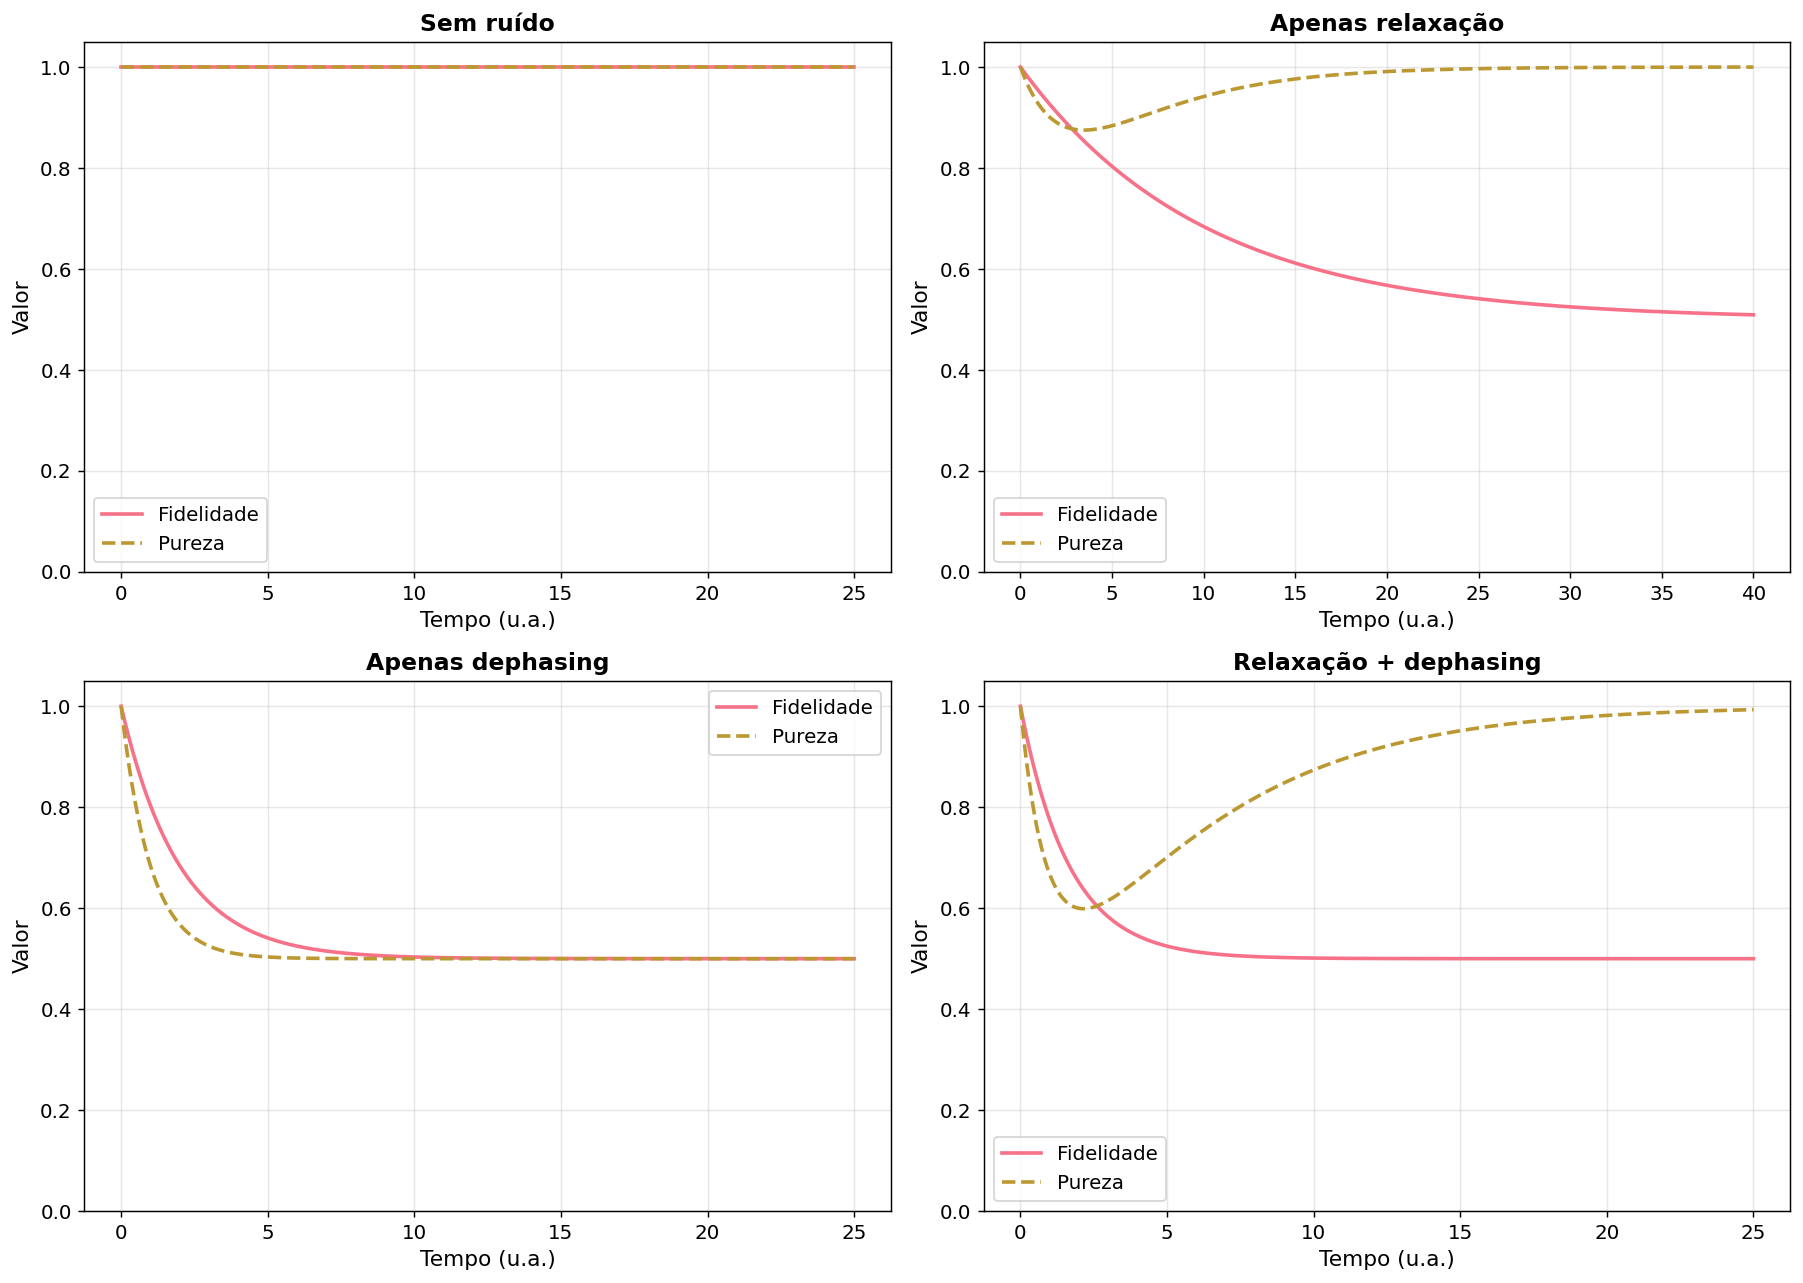

In [21]:
# ============================================================================
# 4. VISUALIZAÇÕES MELHORADAS
# ============================================================================

print("\n" + "="*80)
print("4.1. Curvas temporais representativas")
print("="*80)

# Selecionar casos típicos
casos_tipicos = [
    ('g1_0.0_gphi_0.0', 'Sem ruído'),
    ('g1_0.2_gphi_0.0', 'Apenas relaxação'),
    ('g1_0.0_gphi_0.5', 'Apenas dephasing'),
    ('g1_0.2_gphi_0.5', 'Relaxação + dephasing')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (tag, label) in enumerate(casos_tipicos):
    ax = axes[idx]
    case_df = full_df[full_df['tag'] == tag]

    t = case_df['t']
    fidelity = case_df['fidelity']
    purity = case_df['purity']

    ax.plot(t, fidelity, label='Fidelidade', linewidth=2)
    ax.plot(t, purity, label='Pureza', linewidth=2, linestyle='--')

    ax.set_xlabel('Tempo (u.a.)', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "casos_tipicos_fidelidade_pureza.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✓ Figura salva: {fig_path}")
plt.show()


## 6. Resultados — Componentes do Vetor de Bloch

**Figura 2 do artigo:** ⟨σx⟩, ⟨σy⟩, ⟨σz⟩ em função do tempo
para o caso γ₁ = 0,2, γ_φ = 0,5.



4.2. Componentes de Bloch (caso com relaxação + dephasing)
✓ Figura salva: results/figures/bloch_components_exemplo.png


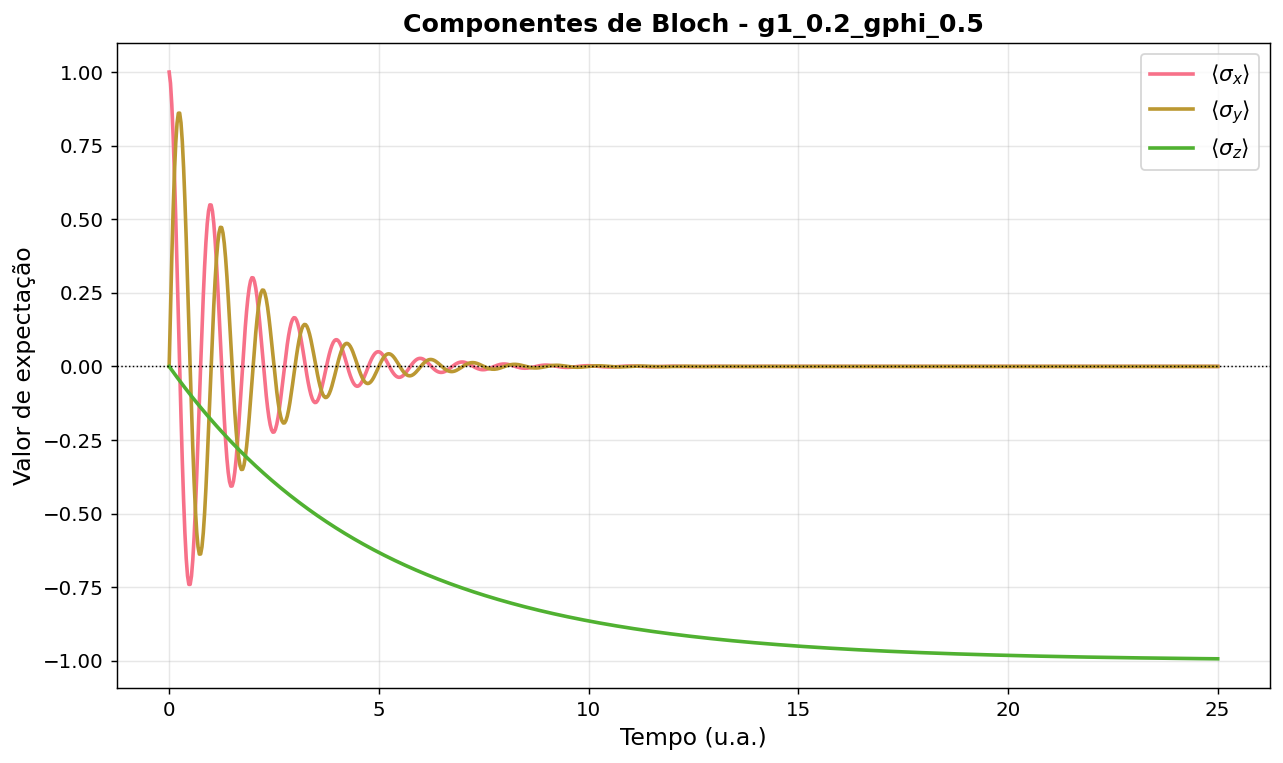

In [23]:
# ============================================================================
# 4.2. Componentes de Bloch para um caso específico
# ============================================================================

print("\n" + "="*80)
print("4.2. Componentes de Bloch (caso com relaxação + dephasing)")
print("="*80)

tag_exemplo = 'g1_0.2_gphi_0.5'
case_df = full_df[full_df['tag'] == tag_exemplo]

t = case_df['t']
sx = case_df['sx']
sy = case_df['sy']
sz = case_df['sz']

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t, sx, label=r'$\langle\sigma_x\rangle$', linewidth=2)
ax.plot(t, sy, label=r'$\langle\sigma_y\rangle$', linewidth=2)
ax.plot(t, sz, label=r'$\langle\sigma_z\rangle$', linewidth=2)

ax.set_xlabel('Tempo (u.a.)', fontsize=13)
ax.set_ylabel('Valor de expectação', fontsize=13)
ax.set_title(f'Componentes de Bloch - {tag_exemplo}', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "bloch_components_exemplo.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✓ Figura salva: {fig_path}")
plt.show()


## 7. Resultados — Convergência Temporal

**Figura 3 do artigo:** análise de convergência para γ₁ = 0,2, γ_φ = 0,5.

Varia N ∈ {25, 50, 100, 200, 400, 800, 1600} pontos com Tfinal fixo.
Painel (a): T₂ estimado vs Δt. Painel (b): erro relativo em escala log-log.
Critério adotado: **N ≥ 200** garante erro < 0,1% frente ao valor convergido.


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


  N=   25  Δt=1.04167  T₂=1.666637 ± 6.89e-07  R²=1.00000
  N=   50  Δt=0.51020  T₂=1.666636 ± 7.19e-07  R²=1.00000
  N=  100  Δt=0.25253  T₂=1.666635 ± 4.51e-07  R²=1.00000
  N=  200  Δt=0.12563  T₂=1.666635 ± 3.15e-07  R²=1.00000
  N=  400  Δt=0.06266  T₂=1.666635 ± 2.20e-07  R²=1.00000
  N=  800  Δt=0.03129  T₂=1.666635 ± 1.53e-07  R²=1.00000
  N= 1600  Δt=0.01563  T₂=1.666635 ± 1.08e-07  R²=1.00000

 Figura 3 salva: results/figures/fig3_convergencia_temporal.png


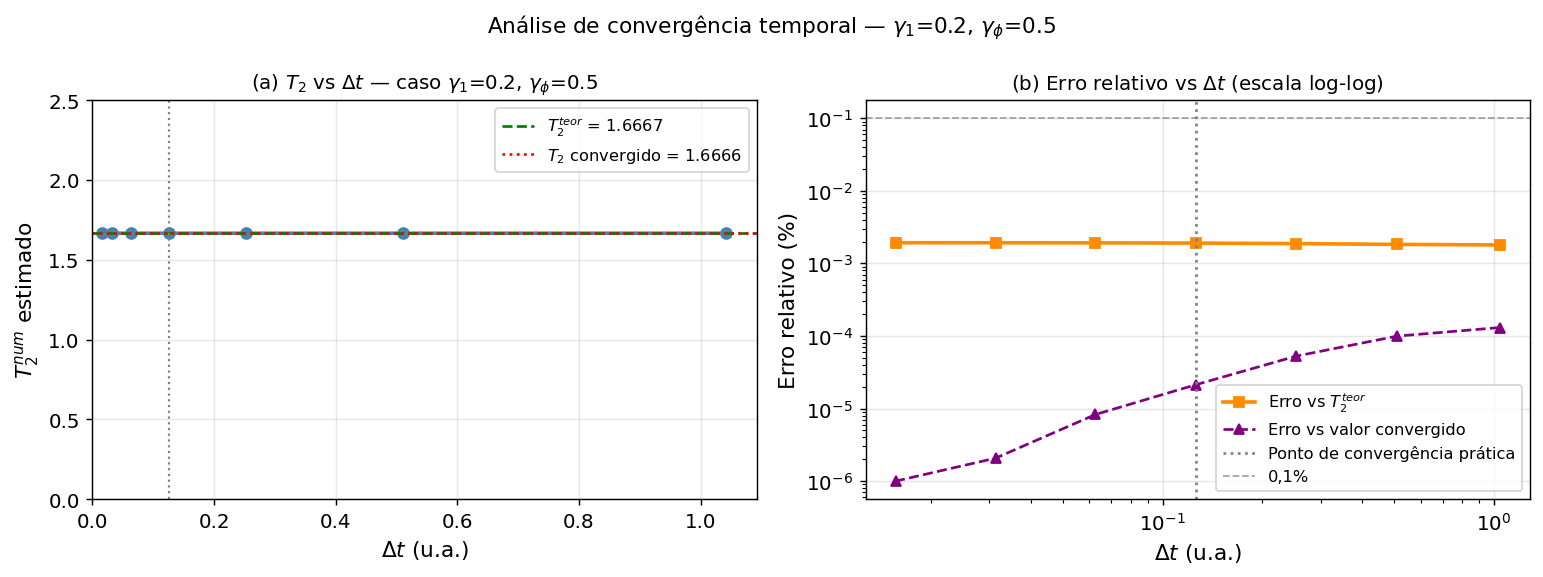


=== TABELA DE CONVERGÊNCIA ===
   N       dt   T2_num   T2_err  R2  erro_rel%  erro_vs_ref%
  25 1.041667 1.666637 0.000001 1.0   0.001799      0.000131
  50 0.510204 1.666636 0.000001 1.0   0.001830      0.000100
 100 0.252525 1.666635 0.000000 1.0   0.001877      0.000053
 200 0.125628 1.666635 0.000000 1.0   0.001908      0.000021
 400 0.062657 1.666635 0.000000 1.0   0.001921      0.000008
 800 0.031289 1.666635 0.000000 1.0   0.001927      0.000002
1600 0.015635 1.666635 0.000000 1.0   0.001929      0.000000

T₂ teórico   : 1.666667 u.a.
T₂ convergido : 1.666635 u.a.
Critério: N≥25 → erro vs valor convergido < 0,1%


In [30]:
# ============================================================
# 7. Convergência temporal  =  Figura 3 do artigo
# ============================================================

g1_conv, gp_conv = 0.2, 0.5
Tf_conv   = tfinal_adaptativo(g1_conv, gp_conv)   # 25.0 u.a.
T2_teor_  = T2_teor(g1_conv, gp_conv)              # 1.6667 u.a.
N_list    = [25, 50, 100, 200, 400, 800, 1600]

conv_rows = []
T2_ref = None

for N in N_list:
    tlist  = np.linspace(0, Tf_conv, N)
    states = simular(g1_conv, gp_conv, tlist)

    # extrair |rho01| manualmente (evita dependência de extrair_obs)
    rho01 = np.array([
        abs((s.proj() if s.isket else s).full()[0, 1])
        for s in states
    ])

    fit = ajusta_exp(tlist, rho01)
    dt  = Tf_conv / (N - 1)
    if N == 1600:
        T2_ref = fit['tau']
    conv_rows.append({'N': N, 'dt': dt,
                      'T2_num': fit['tau'], 'T2_err': fit['err'], 'R2': fit['R2']})
    print(f'  N={N:5d}  Δt={dt:.5f}  T₂={fit["tau"]:.6f} ± {fit["err"]:.2e}  R²={fit["R2"]:.5f}')

df_conv = pd.DataFrame(conv_rows)
df_conv['erro_rel%']    = np.abs(df_conv['T2_num'] - T2_teor_) / T2_teor_ * 100
df_conv['erro_vs_ref%'] = np.abs(df_conv['T2_num'] - T2_ref)   / T2_ref   * 100

# ── Figura 3 — do artigo ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(fr'Análise de convergência temporal — $\gamma_1$={g1_conv}, $\gamma_\phi$={gp_conv}',
             fontsize=12)

# Painel (a): T₂ estimado vs Δt — eixo X linear, Y de 0 a 2.5
ax = axes[0]
ax.plot(df_conv['dt'], df_conv['T2_num'], 'o-', color='steelblue', lw=2, ms=6)
ax.axhline(T2_teor_, color='green', ls='--', lw=1.5,
           label=fr'$T_2^{{teor}}$ = {T2_teor_:.4f}')
ax.axhline(T2_ref,   color='red',   ls=':',  lw=1.5,
           label=fr'$T_2$ convergido = {T2_ref:.4f}')
idx200 = df_conv[df_conv['N'] == 200].index[0]
ax.axvline(df_conv.loc[idx200, 'dt'], color='gray', ls=':', lw=1.2)
ax.set_xlim(left=0)
ax.set_ylim(0, 2.5)
ax.set_xlabel(r'$\Delta t$ (u.a.)', fontsize=12)
ax.set_ylabel(r'$T_2^{num}$ estimado', fontsize=12)
ax.set_title(fr'(a) $T_2$ vs $\Delta t$ — caso $\gamma_1$={g1_conv}, $\gamma_\phi$={gp_conv}',
             fontsize=11)
ax.legend(fontsize=9)

# Painel (b): erro relativo log-log
ax = axes[1]
ax.loglog(df_conv['dt'], df_conv['erro_rel%'].clip(1e-6), 's-',
          color='darkorange', lw=2, ms=6, label=r'Erro vs $T_2^{teor}$')
ax.loglog(df_conv['dt'], df_conv['erro_vs_ref%'].clip(1e-6), '^--',
          color='purple', lw=1.5, ms=6, label='Erro vs valor convergido')
ax.axvline(df_conv.loc[idx200, 'dt'], color='gray', ls=':', lw=1.5,
           label='Ponto de convergência prática')
ax.axhline(0.1, color='gray', ls='--', lw=1.0, alpha=0.7, label='0,1%')
ax.set_xlabel(r'$\Delta t$ (u.a.)', fontsize=12)
ax.set_ylabel('Erro relativo (%)', fontsize=12)
ax.set_title(r'(b) Erro relativo vs $\Delta t$ (escala log-log)', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'fig3_convergencia_temporal.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'\n Figura 3 salva: {fig_path}')
plt.show()

print('\n=== TABELA DE CONVERGÊNCIA ===')
print(df_conv[['N','dt','T2_num','T2_err','R2','erro_rel%','erro_vs_ref%']].round(6).to_string(index=False))
N_conv = df_conv[df_conv['erro_vs_ref%'] < 0.1]['N'].min()
print(f'\nT₂ teórico   : {T2_teor_:.6f} u.a.')
print(f'T₂ convergido : {T2_ref:.6f} u.a.')
print(f'Critério: N≥{N_conv} → erro vs valor convergido < 0,1%')


## 8. Resultados — Invariância ao Estado Inicial

**Figura 4 do artigo:** T₂ via |ρ₀₁(t)| para três estados iniciais
(|+⟩, |−⟩, |+i⟩) com γ₁ = 0,2, γ_φ = 0,5.

Painel (a): |ρ₀₁(t)| — curvas sobrepostas, T₂ concordante dentro de 0,01%.
Painel (b): fidelidade F(t) — varia com o estado de referência,
evidenciando que |ρ₀₁| é a métrica mais robusta para estimar T₂.


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


✓ Figura 4 salva: results/figures/fig4_invariancia_estado_inicial.png


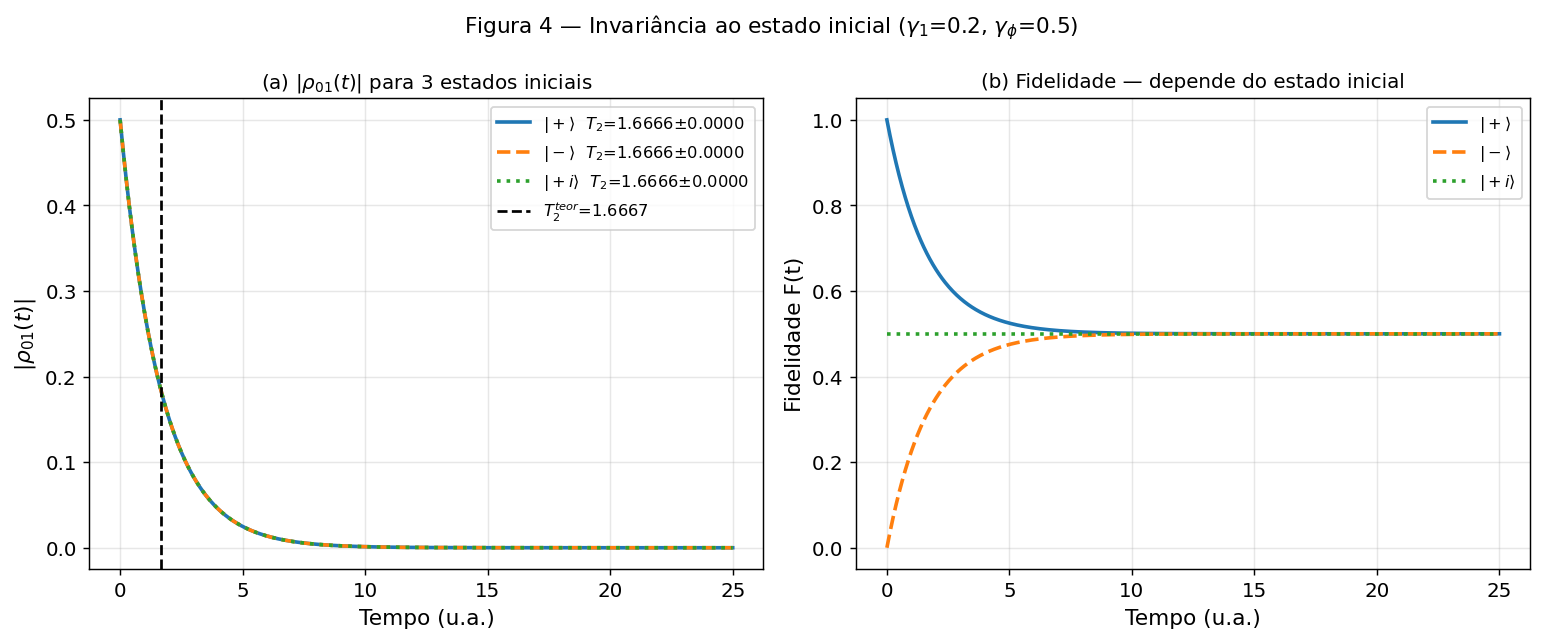


=== T₂ PARA DIFERENTES ESTADOS INICIAIS ===
      Estado   T2_num  T2_err  R2  T2_teor    erro%
 $|+\rangle$ 1.666635     0.0 1.0 1.666667 0.001927
 $|-\rangle$ 1.666635     0.0 1.0 1.666667 0.001927
$|+i\rangle$ 1.666635     0.0 1.0 1.666667 0.001927

Desvio relativo máximo entre estados: 0.0000%
|ρ₀₁| é invariante ao estado inicial — escolha de |+⟩ é válida.


In [34]:
# ============================================================
# 8. Invariância ao estado inicial  =  Figura 4 do artigo
# Painel (a): |ρ₀₁(t)| — curvas sobrepostas para 3 estados iniciais
# Painel (b): F(t) calculada em relação à evolução ideal de |+⟩
#             para cada estado inicial (mostra que F varia, |ρ₀₁| não)
# ============================================================

g1_si, gp_si = 0.2, 0.5
Tf_si    = tfinal_adaptativo(g1_si, gp_si)
tlist_si = np.linspace(0, Tf_si, 800)
T2_th_si = T2_teor(g1_si, gp_si)

# Estado de referência para cálculo da fidelidade no painel (b)
psi_ref  = (basis(2, 0) + basis(2, 1)).unit()   # |+⟩
psi_ref_t = [((-1j * H * t).expm() * psi_ref) for t in tlist_si]

estados_iniciais = {
    r'$|+\rangle$':  (basis(2, 0) + basis(2, 1)).unit(),
    r'$|-\rangle$':  (basis(2, 0) - basis(2, 1)).unit(),
    r'$|+i\rangle$': (basis(2, 0) + 1j * basis(2, 1)).unit(),
}
cores  = ['tab:blue', 'tab:orange', 'tab:green']
styles = ['-', '--', ':']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

si_rows = []
for (label, psi0), cor, ls in zip(estados_iniciais.items(), cores, styles):
    sts   = simular(g1_si, gp_si, tlist_si, psi0=psi0)
    rho01 = np.array([abs((s.proj() if s.isket else s).full()[0, 1]) for s in sts])
    fit   = ajusta_exp(tlist_si, rho01)

    # Painel (a): |ρ₀₁(t)|
    lbl_a = label + f'  $T_2$={fit["tau"]:.4f}±{fit["err"]:.4f}'
    axes[0].plot(tlist_si, rho01, lw=2, color=cor, ls=ls, label=lbl_a)

    # Painel (b): fidelidade em relação à evolução ideal de |+⟩
    fid = []
    for k, s in enumerate(sts):
        rho_dm = s.proj() if s.isket else s
        raw = psi_ref_t[k].dag() * rho_dm * psi_ref_t[k]
        fid.append(float(np.real(raw.tr() if hasattr(raw, 'tr') else raw)))
    axes[1].plot(tlist_si, fid, lw=2, color=cor, ls=ls, label=label)

    si_rows.append({'Estado': label, 'T2_num': fit['tau'],
                    'T2_err': fit['err'], 'R2': fit['R2'],
                    'T2_teor': T2_th_si,
                    'erro%': abs(fit['tau'] - T2_th_si) / T2_th_si * 100})

# Linha vertical T₂ teórico no painel (a)
axes[0].axvline(T2_th_si, color='black', ls='--', lw=1.5,
                label=fr'$T_2^{{teor}}$={T2_th_si:.4f}')
axes[0].set_xlabel('Tempo (u.a.)', fontsize=12)
axes[0].set_ylabel(r'$|\rho_{01}(t)|$', fontsize=12)
axes[0].set_title(r'(a) $|\rho_{01}(t)|$ para 3 estados iniciais', fontsize=11)
axes[0].legend(fontsize=9)

axes[1].set_xlabel('Tempo (u.a.)', fontsize=12)
axes[1].set_ylabel('Fidelidade F(t)', fontsize=12)
axes[1].set_title('(b) Fidelidade — depende do estado inicial', fontsize=11)
axes[1].legend(fontsize=9)

fig.suptitle(fr'Figura 4 — Invariância ao estado inicial '
             fr'($\gamma_1$={g1_si}, $\gamma_\phi$={gp_si})',
             fontsize=12)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'fig4_invariancia_estado_inicial.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'✓ Figura 4 salva: {fig_path}')
plt.show()

df_si = pd.DataFrame(si_rows)
print('\n=== T₂ PARA DIFERENTES ESTADOS INICIAIS ===')
print(df_si.round(6).to_string(index=False))
print(f'\nDesvio relativo máximo entre estados: '
      f'{df_si["T2_num"].std()/df_si["T2_num"].mean()*100:.4f}%')
print('|ρ₀₁| é invariante ao estado inicial — escolha de |+⟩ é válida.')


## 9. Resultados — Mapas Paramétricos de Decoerência

**Figura 5:** mapa de calor de T₂ⁿᵘᵐ em função de γ₁ e γ_φ.  
**Figura 6:** mapa de calor da pureza final P(Tfinal).


✓ Figura 5 salva: results/figures/fig5_heatmap_T2.png


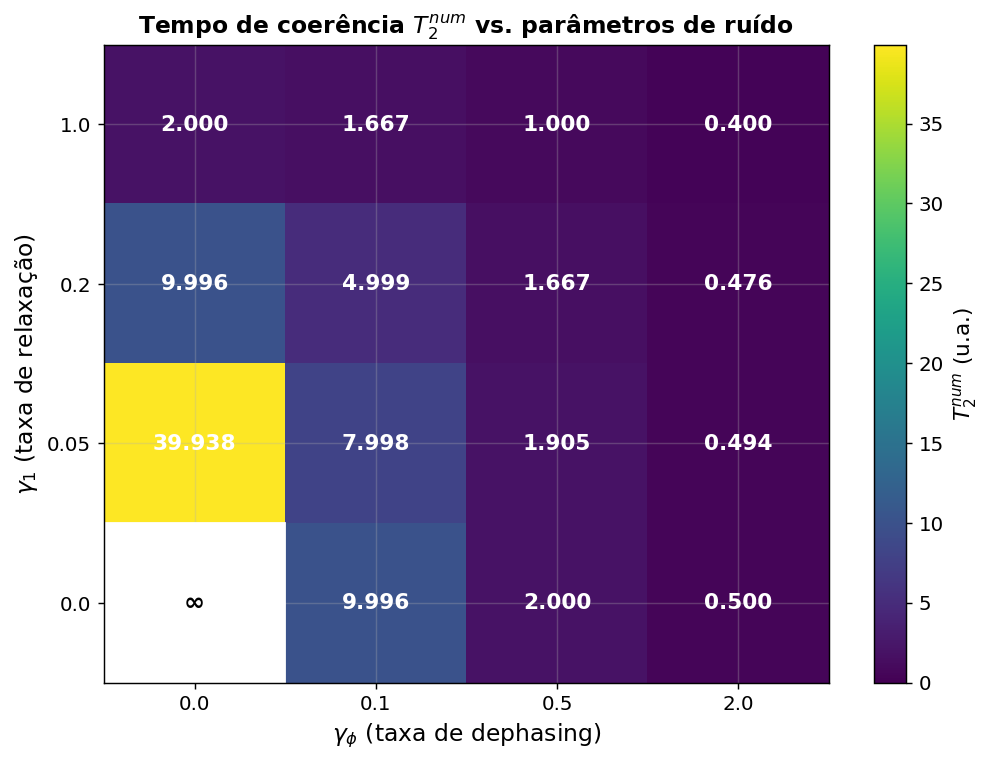

In [38]:
# ============================================================
# 9.1 Heatmap T₂ⁿᵘᵐ  =  Figura 5 do artigo
# ============================================================

gamma1_vals = sorted(summary_enhanced['gamma1'].unique(), reverse=True)
gphi_vals   = sorted(summary_enhanced['gphi'].unique())

pivot_T2 = summary_enhanced.pivot(index='gamma1', columns='gphi', values='T2_num')
pivot_T2 = pivot_T2.reindex(index=gamma1_vals, columns=gphi_vals)
Z = pivot_T2.values.astype(float)

vmax = np.nanmax(Z[np.isfinite(Z)])
Z_plot = np.where(np.isfinite(Z), Z, vmax)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Z_plot, aspect='auto', cmap='viridis', vmin=0, vmax=vmax)

for i, g1 in enumerate(gamma1_vals):
    for j, gp in enumerate(gphi_vals):
        val = Z[i, j]
        if not np.isfinite(val) or val > 999:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                         color='white', zorder=2))
            ax.text(j, i, '∞', ha='center', va='center',
                    color='black', fontsize=14, fontweight='bold', zorder=3)
        else:
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    color='white', fontsize=12, fontweight='bold')

ax.set_xticks(range(len(gphi_vals)))
ax.set_xticklabels([str(g) for g in gphi_vals], fontsize=11)
ax.set_yticks(range(len(gamma1_vals)))
ax.set_yticklabels([str(g) for g in gamma1_vals], fontsize=11)
ax.set_xlabel(r'$\gamma_\phi$ (taxa de dephasing)', fontsize=13)
ax.set_ylabel(r'$\gamma_1$ (taxa de relaxação)', fontsize=13)
ax.set_title(r'Tempo de coerência $T_2^{num}$ vs. parâmetros de ruído',
             fontsize=13, fontweight='bold')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$T_2^{num}$ (u.a.)', fontsize=12)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'fig5_heatmap_T2.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'✓ Figura 5 salva: {fig_path}')
plt.show()


✓ Figura 6 salva: results/figures/fig6_heatmap_pureza.png


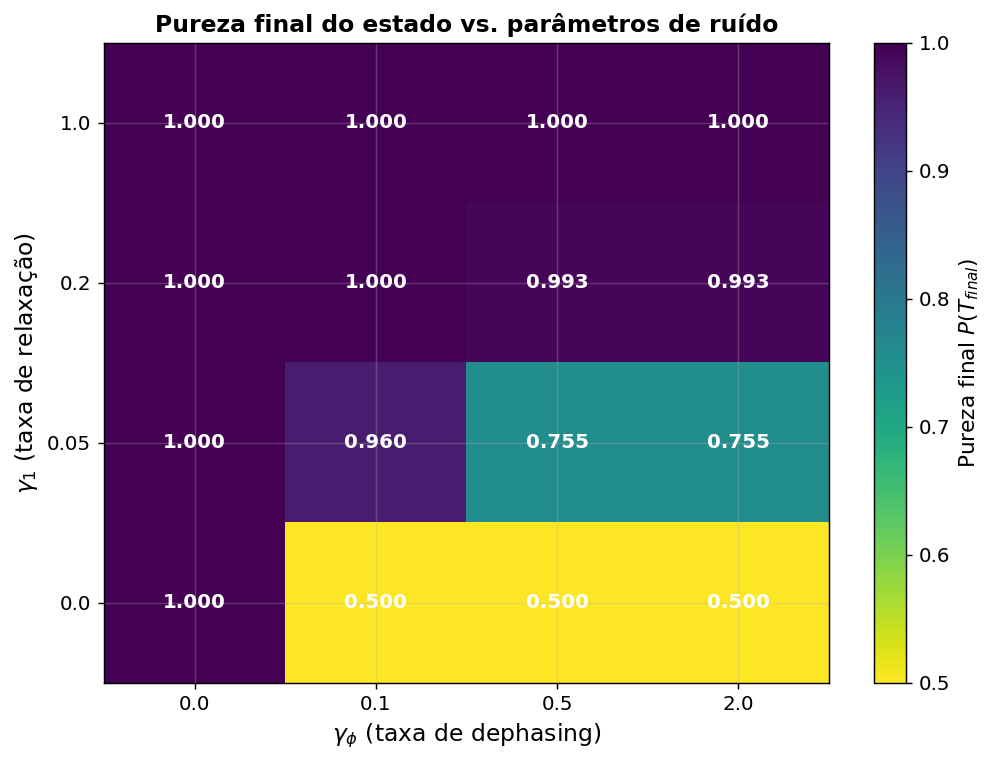

In [39]:
# ============================================================
# 9.2 Heatmap pureza final  =  Figura 6 do artigo
# ============================================================

gamma1_vals = sorted(summary_enhanced['gamma1'].unique(), reverse=True)
gphi_vals   = sorted(summary_enhanced['gphi'].unique())

pivot_pur = summary_enhanced.pivot(index='gamma1', columns='gphi', values='purity_final')
pivot_pur = pivot_pur.reindex(index=gamma1_vals, columns=gphi_vals)
Z_pur = pivot_pur.values.astype(float)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Z_pur, aspect='auto', cmap='viridis_r', vmin=0.5, vmax=1.0)

for i in range(len(gamma1_vals)):
    for j in range(len(gphi_vals)):
        val = Z_pur[i, j]
        txt = f'{val:.3f}' if np.isfinite(val) else '—'
        ax.text(j, i, txt, ha='center', va='center',
                color='white', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(gphi_vals)))
ax.set_xticklabels([str(g) for g in gphi_vals], fontsize=11)
ax.set_yticks(range(len(gamma1_vals)))
ax.set_yticklabels([str(g) for g in gamma1_vals], fontsize=11)
ax.set_xlabel(r'$\gamma_\phi$ (taxa de dephasing)', fontsize=13)
ax.set_ylabel(r'$\gamma_1$ (taxa de relaxação)', fontsize=13)
ax.set_title('Pureza final do estado vs. parâmetros de ruído',
             fontsize=13, fontweight='bold')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'Pureza final $P(T_{final})$', fontsize=12)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'fig6_heatmap_pureza.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'✓ Figura 6 salva: {fig_path}')
plt.show()


## 10. Resultados — Validação Numérica vs. Teórica

**Figura 7 do artigo:** T₂ⁿᵘᵐ vs T₂ᵗᵉᵒʳ para todos os casos com T₂ finito.
Linha tracejada = correspondência ideal. Barras de erro = ±1σ.

**Tabela I:** casos típicos com Tfinal adaptativo, T₂ⁿᵘᵐ ± 1σ e R².  
**Tabela II:** resumo completo dos 16 casos simulados.


✓ Figura 7 salva: results/figures/fig7_T2_num_vs_teor.png


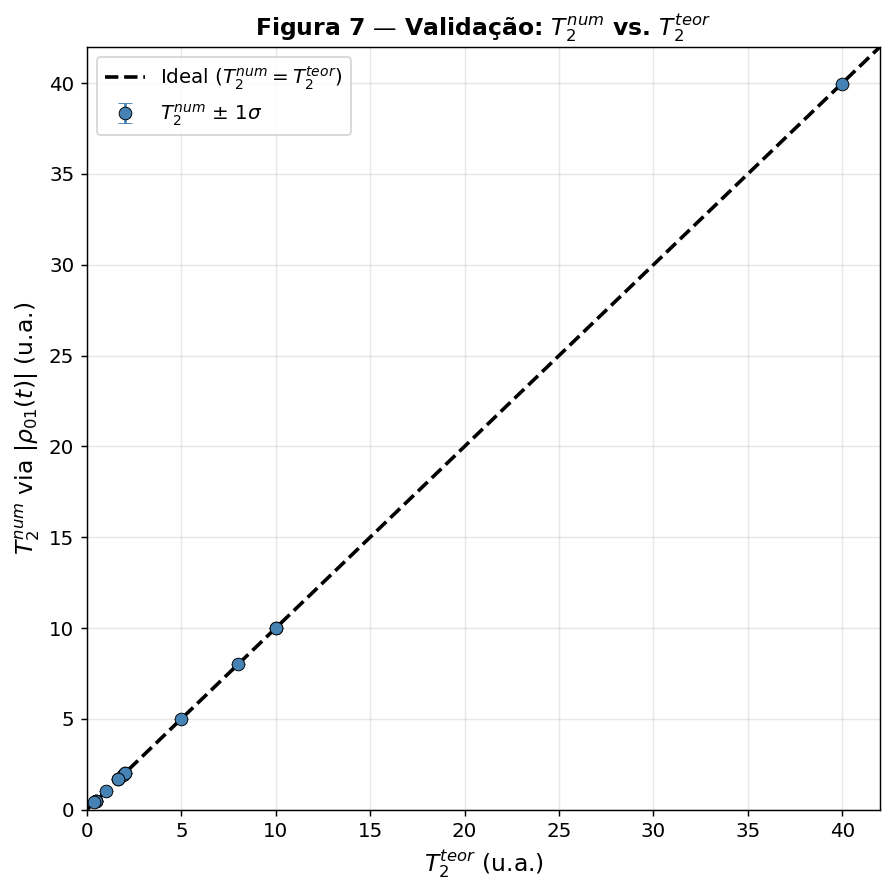


=== CASOS COM T₂ FINITO ===
             tag  gamma1  gphi  Tfinal    T2_num   T2_err  R2     T2_th  erro_rel_T2
 g1_0.0_gphi_0.1    0.00   0.1    80.0  9.996091 0.000027 1.0 10.000000     0.039089
 g1_0.0_gphi_0.5    0.00   0.5    25.0  1.999880 0.000002 1.0  2.000000     0.005984
 g1_0.0_gphi_2.0    0.00   2.0    25.0  0.499999 0.000000 1.0  0.500000     0.000281
g1_0.05_gphi_0.0    0.05   0.0   160.0 39.938141 0.000047 1.0 40.000000     0.154648
g1_0.05_gphi_0.1    0.05   0.1    64.0  7.998195 0.000025 1.0  8.000000     0.022559
g1_0.05_gphi_0.5    0.05   0.5    25.0  1.904638 0.000001 1.0  1.904762     0.006502
g1_0.05_gphi_2.0    0.05   2.0    25.0  0.493826 0.000000 1.0  0.493827     0.000273
 g1_0.2_gphi_0.0    0.20   0.0    40.0  9.996390 0.000037 1.0 10.000000     0.036097
 g1_0.2_gphi_0.1    0.20   0.1    40.0  4.999187 0.000008 1.0  5.000000     0.016269
 g1_0.2_gphi_0.5    0.20   0.5    25.0  1.666635 0.000000 1.0  1.666667     0.001927
 g1_0.2_gphi_2.0    0.20   2.0    25

In [40]:
# ============================================================
# 10. Validação T₂ⁿᵘᵐ vs T₂ᵗᵉᵒʳ  =  Figura 7 do artigo
# ============================================================

valid = summary_enhanced[
    np.isfinite(summary_enhanced['T2_th']) &
    np.isfinite(summary_enhanced['T2_num'])
].copy()

fig, ax = plt.subplots(figsize=(7, 7))

# Diagonal ideal
max_val = max(valid['T2_th'].max(), valid['T2_num'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', lw=2,
        label=r'Ideal ($T_2^{num} = T_2^{teor}$)')

# Scatter com barras de erro ±1σ
ax.errorbar(valid['T2_th'], valid['T2_num'],
            yerr=valid['T2_err'],
            fmt='o', color='steelblue', ecolor='steelblue',
            elinewidth=1.5, capsize=4, ms=7,
            markeredgecolor='black', markeredgewidth=0.5,
            label=r'$T_2^{num}$ ± 1$\sigma$')

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel(r'$T_2^{teor}$ (u.a.)', fontsize=13)
ax.set_ylabel(r'$T_2^{num}$ via $|\rho_{01}(t)|$ (u.a.)', fontsize=13)
ax.set_title(r'Figura 7 — Validação: $T_2^{num}$ vs. $T_2^{teor}$',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'fig7_T2_num_vs_teor.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'✓ Figura 7 salva: {fig_path}')
plt.show()

print('\n=== CASOS COM T₂ FINITO ===')
print(valid[['tag','gamma1','gphi','Tfinal','T2_num','T2_err','R2',
             'T2_th','erro_rel_T2']].round(6).to_string(index=False))


## 11. Exportação de Tabelas LaTeX

Gera as tabelas prontas para inserção no artigo.
Salva também em `results/tables/` como CSV.


In [44]:
# ============================================================
# 11.1  Tabela I — Casos típicos
# ============================================================
print('=' * 70)
print('Tabela I — Casos típicos de decoerência')
print('=' * 70)

casos_tipicos = [
    'g1_0.0_gphi_0.0',
    'g1_0.0_gphi_0.5',
    'g1_0.2_gphi_0.0',
    'g1_0.2_gphi_0.5',
    'g1_1.0_gphi_2.0',
]

tab1 = summary_enhanced[summary_enhanced['tag'].isin(casos_tipicos)].copy()
tab1 = tab1[['tag', 'gamma1', 'gphi', 'fidelity_final', 'purity_final',
              'T2_num', 'T2_th', 'erro_rel_T2']]
tab1.columns = ['Caso', 'γ₁', 'γ_φ', 'F(Tf)', 'P(Tf)',
                'T₂ⁿᵘᵐ', 'T₂ᵗᵉᵒʳ', 'Erro rel. (%)']
display(tab1)

latex1 = tab1.to_latex(index=False, float_format='%.4f',
                        caption='Casos típicos de decoerência — estimativas via $|\\rho_{01}(t)|$.',
                        label='tab:casos_tipicos')
tab1_path = os.path.join(TABLES_DIR, 'tabela_I_casos_tipicos.tex')
with open(tab1_path, 'w') as f:
    f.write(latex1)
print(f'\nLaTeX salvo em {tab1_path}')


Tabela I — Casos típicos de decoerência


,Caso,γ₁,γ_φ,F(Tf),P(Tf),T₂ⁿᵘᵐ,T₂ᵗᵉᵒʳ,Erro rel. (%)
0,g1_0.0_gphi_0.0,0.0,0.0,1.000000,1.000000,inf,inf,NaN
2,g1_0.0_gphi_0.5,0.0,0.5,0.500002,0.500000,1.999880,2.000000,0.005984
8,g1_0.2_gphi_0.0,0.2,0.0,0.509142,0.999832,9.996390,10.000000,0.036097
10,g1_0.2_gphi_0.5,0.2,0.5,0.500000,0.993285,1.666635,1.666667,0.001927
15,g1_1.0_gphi_2.0,1.0,2.0,0.500000,1.000000,0.400000,0.400000,0.000020



LaTeX salvo em results/tables/tabela_I_casos_tipicos.tex


In [45]:
# ============================================================
# 11.2  Tabela II — Resumo completo dos 16 casos
# ============================================================
print('=' * 70)
print('Tabela II — Resumo completo dos 16 casos')
print('=' * 70)

tab2 = summary_enhanced[[
    'gamma1', 'gphi', 'fidelity_final', 'purity_final',
    'T2_num', 'T2_th', 'erro_rel_T2'
]].copy()
tab2.columns = ['γ₁', 'γ_φ', 'F(Tf)', 'P(Tf)',
                'T₂ⁿᵘᵐ', 'T₂ᵗᵉᵒʳ', 'Erro rel. (%)']
display(tab2)

latex2 = tab2.to_latex(index=False, float_format='%.4f',
                        caption='Resumo dos resultados numéricos — estimativa de $T_2$ via $|\\rho_{01}(t)|$.',
                        label='tab:resumo_completo')
tab2_path = os.path.join(TABLES_DIR, 'tabela_II_resumo_completo.tex')
with open(tab2_path, 'w') as f:
    f.write(latex2)
print(f'\nLaTeX salvo em {tab2_path}')


Tabela II — Resumo completo dos 16 casos


,γ₁,γ_φ,F(Tf),P(Tf),T₂ⁿᵘᵐ,T₂ᵗᵉᵒʳ,Erro rel. (%)
0,0.00,0.0,1.000000,1.000000,inf,inf,NaN
1,0.00,0.1,0.500167,0.500000,9.996091,10.000000,0.039089
2,0.00,0.5,0.500002,0.500000,1.999880,2.000000,0.005984
3,0.00,2.0,0.500000,0.500000,0.499999,0.500000,0.000281
4,0.05,0.0,0.509101,0.999830,39.938141,40.000000,0.154648
5,0.05,0.1,0.500167,0.960069,7.998195,8.000000,0.022559
6,0.05,0.5,0.500001,0.754538,1.904638,1.904762,0.006502
7,0.05,2.0,0.500000,0.754538,0.493826,0.493827,0.000273
8,0.20,0.0,0.509142,0.999832,9.996390,10.000000,0.036097
9,0.20,0.1,0.500167,0.999665,4.999187,5.000000,0.016269



LaTeX salvo em results/tables/tabela_II_resumo_completo.tex


## 12. Relatório Final

Imprime um resumo quantitativo dos resultados, espelhando a Seção V do artigo.


In [48]:
# ============================================================
# 12. Relatório final
# ============================================================
print('=' * 70)
print('RELATÓRIO FINAL — ANÁLISE DE DECOERÊNCIA EM QUBITS')
print('=' * 70)

n_casos = len(summary_enhanced)
validos = summary_enhanced[np.isfinite(summary_enhanced['T2_th'])]

print(f'\n RESUMO GERAL')
print(f'   Casos simulados  : {n_casos}')
print(f'   Grade γ₁         : {sorted(summary_enhanced["gamma1"].unique())}')
print(f'   Grade γ_φ        : {sorted(summary_enhanced["gphi"].unique())}')

print(f'\n MÉTRICAS T₂ (casos com T₂ finito, N={len(validos)})')
print(f'   Erro relativo médio  : {validos["erro_rel_T2"].mean():.4f} %')
print(f'   Erro relativo máximo : {validos["erro_rel_T2"].max():.4f} %')
print(f'   Concordância >99,9%  : {(validos["erro_rel_T2"] < 0.1).sum()} / {len(validos)} casos')

print(f'\n FIDELIDADE E PUREZA FINAIS')
print(f'   Fidelidade média  : {summary_enhanced["fidelity_final"].mean():.4f}')
print(f'   Pureza média      : {summary_enhanced["purity_final"].mean():.4f}')

print(f'\n ARQUIVOS GERADOS')
print(f'   {os.path.abspath(RESULTS_DIR)}/')
for arq in sorted(glob.glob(os.path.join(RESULTS_DIR, '**/*'), recursive=True)):
    if os.path.isfile(arq):
        print(f'   └── {os.path.relpath(arq, RESULTS_DIR)}')


RELATÓRIO FINAL — ANÁLISE DE DECOERÊNCIA EM QUBITS

 RESUMO GERAL
   Casos simulados  : 16
   Grade γ₁         : [np.float64(0.0), np.float64(0.05), np.float64(0.2), np.float64(1.0)]
   Grade γ_φ        : [np.float64(0.0), np.float64(0.1), np.float64(0.5), np.float64(2.0)]

 MÉTRICAS T₂ (casos com T₂ finito, N=15)
   Erro relativo médio  : 0.0196 %
   Erro relativo máximo : 0.1546 %
   Concordância >99,9%  : 14 / 15 casos

 FIDELIDADE E PUREZA FINAIS
   Fidelidade média  : 0.5324
   Pureza média      : 0.8722

 ARQUIVOS GERADOS
   /content/results/
   └── all_results.pkl
   └── figures/bloch_components_exemplo.png
   └── figures/casos_tipicos_fidelidade_pureza.png
   └── figures/fig3_convergencia_temporal.png
   └── figures/fig4_invariancia_estado_inicial.png
   └── figures/fig5_heatmap_T2.png
   └── figures/fig6_heatmap_pureza.png
   └── figures/fig7_T2_num_vs_teor.png
   └── full_data_consolidated.csv
   └── g1_0.05_gphi_0.0.csv
   └── g1_0.05_gphi_0.1.csv
   └── g1_0.05_gphi_0.5.csv